# NBA Draft Predictive Model

This notebook builds a machine learning model to predict NBA career impact from **pre-draft information only** — draft position, college statistics, and NBA Combine measurements.

The goal is to identify which players overperformed or underperformed relative to what their pre-draft data suggested. The final predictions are exported to Tableau for visualization.

**Data source:** `tableau_nba_draft_master.csv` — the cleaned master dataset built in `data_clean.ipynb`, containing draft history (2010–2025), NBA Combine measurements, and college statistics from toRvik.

**Workflow:**
1. Define a **runway-neutral** target variable (rate-based NBA impact)
2. Select pre-draft features (no data leakage, no draft-age proxy)
3. Train a Random Forest model inside a Pipeline
4. Compare against a Ridge baseline, validate with cross-validation, and stress-test with a time-based split
5. Analyze and visualize feature importance
6. Visualize out-of-fold actual vs predicted outcomes
7. Export honest (out-of-fold) over/underperformer labels for Tableau
8. Identify hidden gems by draft class
9. Player lookup

> **Room for Improvement:** the gold-standard target would be a fixed *first 3-5 year* impact window, which will fully remove runway. This would require season-by-season NBA logs (not in this dataset) — a documented next step is to scrape per-season data from Basketball Reference and rebuild the target on a fixed window. Currently, our `career totals` is aggregrate and there is no constraint on time each player spent in the league.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import cross_validate, cross_val_predict, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

## Step 1 — Define a Runway-Neutral Target Variable

An obvious impact score would combine career Win Shares (WS) and VORP. But those are *cumulative totals* — a player drafted in 2010 has had 15 seasons to accumulate value, while a 2024 pick has had one. 

We want to answer one question: Which NBA success metric is least tied to career length?


In [9]:
df = pd.read_csv("data/tableau_nba_draft_master.csv")

# filter players to those with at least 50 games
MIN_GAMES = 50
qual = pd.to_numeric(df["G"], errors="coerce").fillna(0) >= 50
sub = df.loc[qual].copy()

# converts columns to numeric
for c in ["Yrs", "WS", "VORP", "BPM", "WS/48"]:
    sub[c] = pd.to_numeric(sub[c], errors="coerce")

# computes z-scores
def zscore_avg(frame, cols):
    zs = [(frame[c] - frame[c].mean()) / frame[c].std() for c in cols]
    return pd.concat(zs, axis=1).mean(axis=1)

# calculates "total impact"
sub["total_impact"] = zscore_avg(sub, ["WS", "VORP"])

rows = {
    "Career-total impact (WS+VORP z-avg)": sub["Yrs"].corr(sub["total_impact"]),
    "WS (total)": sub["Yrs"].corr(sub["WS"]),
    "VORP (total)": sub["Yrs"].corr(sub["VORP"]),
    "BPM (rate)": sub["Yrs"].corr(sub["BPM"]),
    "WS/48 (rate)": sub["Yrs"].corr(sub["WS/48"]),
}

pd.Series(rows).round(2)

Career-total impact (WS+VORP z-avg)    0.69
WS (total)                             0.77
VORP (total)                           0.58
BPM (rate)                             0.51
WS/48 (rate)                           0.43
dtype: float64

The strongest correlation with career length is `WS (total)`. This makes sense because playing more seasons means you have more time to accumulate more wins.

A more runway-neutral variable would be `WS/48`, a rate metric that meansures win shares per 48 minutes. This allows us to compare how good they are when they're on the court, not how long they've been around.


A feature correlated with draft age (e.g. `DraftYear`) would let the model cheat by learning runway instead of talent.

We will use **rate** statistics that are not inflated by career length:
- **BPM** — Box Plus/Minus, contribution per 100 possessions vs league average
- **WS/48** — Win Shares per 48 minutes

Each is standardized (z-scored) across qualified players and averaged into a single `rate_impact` score. This puts the two metrics on a common scale so neither dominates by units.

**Minimum-sample filter.** Rate stats are noisy for players with very few minutes, so we will add a constraint of **≥ 50 career games**. Naturally, this works out well for us because it also excludes the most recent draft classes, who have not yet played enough to have a stable rate.


In [10]:
df = pd.read_csv("tableau_nba_draft_master.csv")

MIN_GAMES = 50
RATE_COLS = ["BPM", "WS/48"]

# learn standardization params from players with a stable NBA sample only
qual_mask = df["G"].fillna(0) >= MIN_GAMES
scaling = {c: (df.loc[qual_mask, c].mean(), df.loc[qual_mask, c].std())
           for c in RATE_COLS}

# builds a single career-quality score for each player by averaging two standardized rate stats: BPM and WS/48.
def rate_impact(frame):
    zs = []
    for c in RATE_COLS:
        mu, sigma = scaling[c]
        zs.append((frame[c] - mu) / sigma)
    return pd.concat(zs, axis=1).mean(axis=1)

df["rate_impact"] = rate_impact(df)

# create our clean training data set
model_df = df[qual_mask & df["rate_impact"].notna()].copy()
print(f"Qualified players (>= {MIN_GAMES} career games): {len(model_df)}")

Qualified players (>= 50 career games): 691


## Step 2 — Select Features (No Data Leakage, No Runway Proxy)

Features are grouped into three categories, all known **before** a player's NBA career begins:

| Category | Examples |
|---|---|
| **Draft context** | Pick number |
| **College performance** | BPM, scoring, assists, shooting efficiency, usage rate |
| **NBA Combine measurements** | Weight, vertical jump, sprint time, lane agility, bench press |

"Can we predict NBA success using only information available on draft night?"

To prevent **data leakage**, we will exclude:

- **NBA career stats (BPM, VORP, WS, points, rebounds)**
- **`DraftYear`** — it is a proxy for career length , not talent. We drop it to keep the model focused on player-quality signals rather than *when* a player was drafted.

Indicator flags (`has_college_stats`, `has_combine_data`) let the model learn that players with missing pre-draft data (e.g. international prospects) may follow different patterns.

In [12]:
feature_cols = [
    "Pk",

    "college_year_gap",
    "college_g",
    "college_mpg",
    "college_ppg",
    "college_rpg",
    "college_apg",
    "college_bpm",
    "college_obpm",
    "college_dbpm",
    "college_porpag",
    "college_ortg",
    "college_drtg",
    "college_usg",
    "college_ts",
    "college_efg",
    "college_three_pct",

    "combine_weight_lbs",
    "Standing vertical Jump",
    "Maximum Vertical Jump (with steps)",
    "three-quarter court sprint",
    "lane agility drill",
    "Bench Press test",

    "has_college_stats",
    "has_combine_data",
]

X = model_df[feature_cols]
y = model_df["rate_impact"]

print(f"{len(feature_cols)} features")

25 features


## Step 3 — Build and Train the Model

The model is a **Random Forest Regressor** wrapped in a **scikit-learn Pipeline**.

We chose Random Forest as Draft outcomes are full of conditional relationships. It is not necessarily true and doesn't make sense for every feature to contribute independently and linearly.

Our pipeline chains a `SimpleImputer` (median fill) with the model so that, during cross-validation, the imputer is fit **only on each training fold** — preventing test-fold information from leaking into the imputed values.

**Hyperparameters:** `n_estimators=300`, `max_depth=6` (no memorizing individual players), `min_samples_leaf=5` (must make predictions based on groups).

In [ ]:
def make_model():
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42,
        )),
    ])

# Shuffled folds: the rows are in draft order, so unshuffled folds would basically group
# players by draft class.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

model = make_model()
model.fit(X, y)
print("Model fit on", len(X), "qualified players")

Model fit on 691 qualified players


## Step 4 — Baseline Comparison, Cross-Validation, and a Time-Based Split

Three checks, each answering a different question:

1. **Ridge baseline** — does our model beat a simple linear alternative? We want to make sure that we aren't doing all this for nothing.
2. **5-fold cross-validation** — instead of one lucky/unlucky train/test split, every player is in the test fold exactly once. 
3. **Time-based split** — train on older classes (≤ 2018) and test on newer ones (≥ 2019). This is the honest test of whether the model *generalizes to future drafts*, which is how it would actually be used. Random CV can be optimistic because it lets the model see players from every era during training, but it might also be relevant to consider the fact that the NBA is constantly evolving.

**Metrics:** R² and Mean Absolute Error


In [15]:
baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", Ridge()),
])
    
bl = cross_validate(baseline, X, y, cv=cv,
                    scoring=["r2", "neg_mean_absolute_error"])
rf = cross_validate(make_model(), X, y, cv=cv,
                    scoring=["r2", "neg_mean_absolute_error"])

cv_r2, cv_mae = rf["test_r2"], -rf["test_neg_mean_absolute_error"]
bl_r2, bl_mae = bl["test_r2"], -bl["test_neg_mean_absolute_error"]

print(f"{'Model':<20} {'R2 Mean':>9} {'R2 Std':>8} {'MAE Mean':>9}")
print("-" * 48)
print(f"{'Ridge (baseline)':<20} {bl_r2.mean():>9.3f} {bl_r2.std():>8.3f} {bl_mae.mean():>9.3f}")
print(f"{'Random Forest':<20} {cv_r2.mean():>9.3f} {cv_r2.std():>8.3f} {cv_mae.mean():>9.3f}")
print()
print("Per-fold R2 (RF):", [round(v, 3) for v in cv_r2])

Model                  R2 Mean   R2 Std  MAE Mean
------------------------------------------------
Ridge (baseline)         0.129    0.066     0.691
Random Forest            0.115    0.060     0.705

Per-fold R2 (RF): [np.float64(0.18), np.float64(0.053), np.float64(0.035), np.float64(0.172), np.float64(0.133)]


In [16]:
train_mask = model_df["DraftYear"] <= 2018
test_mask  = model_df["DraftYear"] >= 2019

time_model = make_model()
time_model.fit(X[train_mask], y[train_mask])
time_pred = time_model.predict(X[test_mask])

print(f"Time-based split")
print(f"  train (<= 2018): n = {train_mask.sum()}")
print(f"  test  (>= 2019): n = {test_mask.sum()}")
print(f"  R2  = {r2_score(y[test_mask], time_pred):.3f}")
print(f"  MAE = {mean_absolute_error(y[test_mask], time_pred):.3f}")

Time-based split
  train (<= 2018): n = 385
  test  (>= 2019): n = 306
  R2  = 0.107
  MAE = 0.715


### Interpreting the Results

A modest R² is **expected and honest** here — pre-draft data has inherently limited predictive power. There are many things that goes on behind the scenes that we do not know about for example, injuries, work ethic, coaching, team fit, and etc. These are not things that are included in any pre-draft dataset. With that in mind, this is what our specific number says:

**<u>The scoreboard </u>**

| Check | R² | MAE |
|---|---|---|
| Ridge (baseline), 5-fold CV | 0.129 | 0.691 |
| Random Forest, 5-fold CV | 0.115 | 0.705 |
| Random Forest, time-based split (train ≤2018 / test ≥2019) | 0.107 | 0.715 |

**1. RF vs Ridge — the simpler model wins.** Random Forest does **not** beat the Ridge baseline; it is actually *worse* on both metrics.
There is no measurable nonlinear signal large enough to justify the extra complexity of the forest. The relationships between pre-draft data and NBA rate impact look close to linear, and what little structure exists, a regularized linear model captures at least as well.

**2. Per-fold consistency — unstable.** The RF per-fold R² values are `[0.18, 0.053, 0.035, 0.172, 0.133]`, ranging from ~0.04 to ~0.18. That is a wide spread relative to the mean of 0.115, meaning performance depends heavily on *which* players happen to land in each fold. The best fold is about 5 times larger than the worst fold. We should treat the headline R² as a rough average, not a precise, repeatable score. Our results basically tells us that sometimes the model works in finding meaningful signals, but also struggles sometimes to predict exceptional players whose outcomes are driven by factors not present in our dataset. Completely expected!

**3. Random CV vs time-based split — encouragingly small gap.** We expected the time-based R² to drop noticeably, since predicting *future* draft classes from past ones is harder than random CV. Instead it only fell from 0.115 to **0.107** (MAE 0.705 → 0.715). The model degrades only slightly when forced to generalize forward in time, a sign that the model is learning patterns that are reasonably stable over time.

**Bottom line.** All three checks land in the same narrow band (R² ≈ 0.11–0.13, MAE ≈ 0.69–0.72, i.e. predictions are off by ~0.7 standard deviations of rate impact on average). The takeaways:

- Pre-draft information carries **real but weak** signal about NBA rate impact — better than guessing the mean (R² > 0), but far from a reliable forecast.
- Random Forest earns **no advantage** over a linear baseline on this data, so its main value here is interpretability (feature importance), not predictive lift. 
- The honest conclusion is that the model isn't accurate enough to tell us exactly how good a prospect will be, but it is useful for identifying which players significantly exceeded or fell short of what their pre-draft profile suggested. 

## Step 5 — Feature Importance

Feature importance measures how much each variable reduces prediction error across all 300 trees. It answers: **"What pre-draft signals actually predict NBA rate impact?"** Scores sum to 1.0.

In [17]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

feature_importance.head(15)

,feature,importance
0,combine_weight_lbs,0.182236
1,Pk,0.151486
2,college_dbpm,0.132952
3,college_three_pct,0.084776
4,college_bpm,0.054874
5,college_efg,0.042831
6,college_ortg,0.033879
7,lane agility drill,0.033749
8,three-quarter court sprint,0.031711
9,college_rpg,0.028188


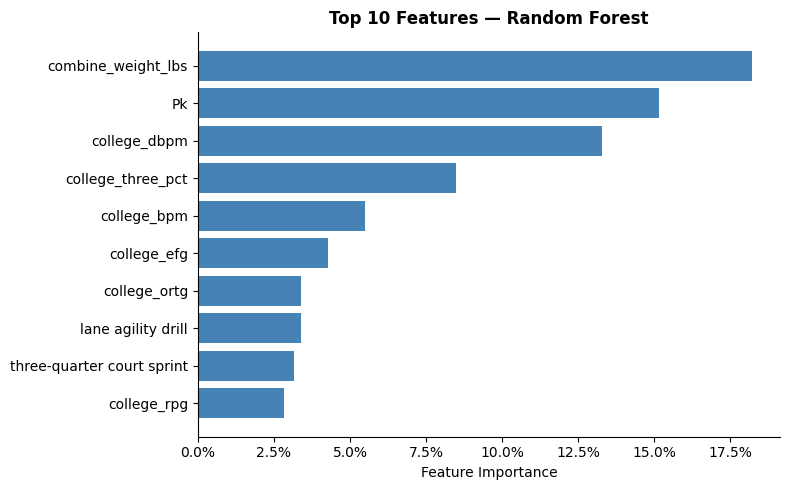

In [18]:
top10 = feature_importance.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["feature"][::-1], top10["importance"][::-1],
        color="steelblue", edgecolor="none")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 10 Features — Random Forest", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### What the Feature Importance Tells Us

The top features come out as:

| Rank | Feature | Importance |
|---|---|---|
| 1 | `combine_weight_lbs` | 0.18 |
| 2 | `Pk` (draft pick) | 0.15 |
| 3 | `college_dbpm` | 0.13 |
| 4 | `college_three_pct` | 0.08 |
| 5 | `college_bpm` | 0.05 |
| 6–10 | `college_efg`, `college_ortg`, lane agility, sprint, `college_rpg` | ~0.03 each |

**The main takeaways:**

- **No single feature dominates.** The top signal (`combine_weight_lbs`) is only ~18% of total importance, and it falls off gradually from there. The model spreads its decisions across many weak signals rather than relying on one — consistent with the modest R² we saw: there is no single definite predictor in pre-draft data.

- **Draft pick (`Pk`) is a top signal, but not #1.** It lands second at ~15%. Pick position encodes the collective scouting judgment of 30 franchises, so it is the consensus the model has to beat — but here physical and college measures collectively outweigh it.

- **Physical measurables matter.** `combine_weight_lbs` ranking first (plus lane agility and sprint in the top 10) says body/athletic profile carries real signal for NBA rate impact — likely a proxy for position, durability, and physical readiness.

- **Quality of play translated better than raw production.** `college_dbpm` (defensive BPM) and `college_bpm` (overall) rank above counting stats like `college_rpg`. Efficiency/shooting (`college_three_pct`, `college_efg`) also show up, while volume scoring does not.

**Bottom line:** beyond draft position, the model places additional weight on physical measurements and college efficiency metrics, suggesting these variables contain information about future NBA impact that is not fully reflected in draft order alone. This makes sense!

## Step 6 — Out-of-Fold Actual vs Predicted

This scatter uses **out-of-fold (OOF) predictions**: every player's prediction comes from a fold that never trained on them. That makes the picture honest — no player is being "predicted" by a model that already saw them.

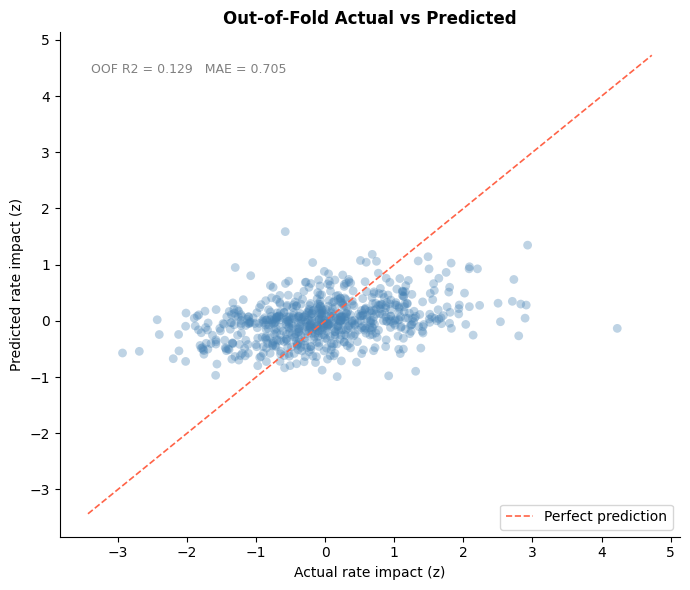

In [19]:
# Honest predictions for every qualified player
oof_pred = cross_val_predict(make_model(), X, y, cv=cv)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, oof_pred, alpha=0.35, color="steelblue", edgecolors="none", s=40)

lims = [min(y.min(), oof_pred.min()) - 0.5, max(y.max(), oof_pred.max()) + 0.5]
ax.plot(lims, lims, color="tomato", linestyle="--", linewidth=1.2,
        label="Perfect prediction")

ax.set_xlabel("Actual rate impact (z)")
ax.set_ylabel("Predicted rate impact (z)")
ax.set_title("Out-of-Fold Actual vs Predicted", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.text(0.05, 0.92,
        f"OOF R2 = {r2_score(y, oof_pred):.3f}   MAE = {mean_absolute_error(y, oof_pred):.3f}",
        transform=ax.transAxes, fontsize=9, color="gray")
plt.tight_layout()
plt.show()

In [20]:
print("Actual std:   ", y.std())
print("Predicted std:", pd.Series(oof_pred).std())
print("Actual range:   ", y.min(), "to", y.max())
print("Predicted range:", min(oof_pred), "to", max(oof_pred))

Actual std:    0.9663621942582841
Predicted std: 0.3779724821347118
Actual range:    -2.932921290536687 to 4.226689462274594
Predicted range: -0.9920192196913227 to 1.5882241413198617


The points form a loose upward-tilted cloud, not a tight line along the diagonal. That visual matches the low OOF R² (~0.1): predictions track actual outcomes a little, but with a lot of scatter. We saw the same pattern in our CV table, --> pre-draft data only explains a small part of NBA rate impact.

We know the model is conservative because predicted rate impact stays clustered near the average (0) while actual outcomes spread much wider.

## Step 7 — Generate Honest Labels and Export for Tableau

The over/underperformer labels are built from the **out-of-fold** predictions above — so a historical player's "overperformance" is never measured against a model that trained on him.

- **`predicted_rate_impact`** — OOF model expectation
- **`impact_vs_prediction`** — actual minus predicted (the residual)
- **`model_result`** — categorical label, using an **adaptive threshold of ±1 standard deviation of the residuals**:
  - `Overperformed Prediction` — residual ≥ +1 SD
  - `Underperformed Prediction` — residual ≤ −1 SD
  - `Near Prediction` — within ±1 SD

Players below the 50-game floor cannot get an honest residual, so they are exported with the label **`Insufficient NBA sample`** rather than a fabricated number. The final CSV is `tableau_nba_draft_model_predictions.csv`.

In [23]:
# OOF predictions -> honest residuals for every qualified player
model_df["predicted_rate_impact"] = oof_pred
# calculate residuals, how much better or worse was the player than expected?
model_df["impact_vs_prediction"] = (
    model_df["rate_impact"] - model_df["predicted_rate_impact"]
)

resid_sd = model_df["impact_vs_prediction"].std()

def label_result(d):
    if d >= resid_sd:
        return "Overperformed Prediction"
    if d <= -resid_sd:
        return "Underperformed Prediction"
    return "Near Prediction"

model_df["model_result"] = model_df["impact_vs_prediction"].apply(label_result)

# Merge labels back onto the full dataset; unqualified players get a clear flag
export = df.merge(
    model_df[["predicted_rate_impact", "impact_vs_prediction", "model_result"]],
    left_index=True, right_index=True, how="left",
)
export["model_result"] = export["model_result"].fillna("Insufficient NBA sample")
export.to_csv("tableau_nba_draft_model_predictions.csv", index=False)

print(f"Residual threshold (1 SD): +/- {resid_sd:.2f}")
print(model_df["model_result"].value_counts().to_string())

Residual threshold (1 SD): +/- 0.90
model_result
Near Prediction              491
Underperformed Prediction    103
Overperformed Prediction      97


### Top Overperformers — Exceeded Out-of-Fold Expectations

The biggest positive residuals: players whose actual rate impact far exceeded what their pre-draft profile predicted, scored out-of-fold. These are the hidden gems — late picks and overlooked prospects who became far better than the data suggested.

In [24]:
cols = ["player", "DraftYear", "Pk", "G",
        "rate_impact", "predicted_rate_impact",
        "impact_vs_prediction", "model_result"]

model_df[cols].sort_values("impact_vs_prediction", ascending=False).head(10).round(2)

,player,DraftYear,Pk,G,rate_impact,predicted_rate_impact,impact_vs_prediction,model_result
280,Nikola Jokić,2014,41,810.0,4.23,-0.13,4.36,Overperformed Prediction
490,Shai Gilgeous-Alexander,2018,11,530.0,2.80,-0.27,3.07,Overperformed Prediction
194,Giannis Antetokounmpo,2013,15,895.0,2.89,0.05,2.84,Overperformed Prediction
74,Kawhi Leonard,2011,15,798.0,2.91,0.28,2.63,Overperformed Prediction
89,Jimmy Butler,2011,30,907.0,2.54,-0.02,2.55,Overperformed Prediction
482,Luka Dončić,2018,3,514.0,2.83,0.30,2.53,Overperformed Prediction
125,Damian Lillard,2012,6,900.0,2.14,-0.25,2.39,Overperformed Prediction
120,Anthony Davis,2012,1,807.0,2.71,0.35,2.36,Overperformed Prediction
119,Isaiah Thomas,2011,60,556.0,1.31,-0.90,2.21,Overperformed Prediction
778,Victor Wembanyama,2023,1,181.0,2.50,0.31,2.19,Overperformed Prediction


### Top Underperformers — Fell Short of Expectations

The biggest negative residuals: players whose pre-draft profile (high pick, strong combine, productive college season) pointed to more than they delivered on a rate basis. Injuries, poor fit, or skills that did not translate. The model surfaces cautionary tales alongside the gems.

In [25]:
model_df[cols].sort_values("impact_vs_prediction", ascending=True).head(10).round(2)

,player,DraftYear,Pk,G,rate_impact,predicted_rate_impact,impact_vs_prediction,model_result
912,Nolan Traoré,2025,19,56.0,-2.43,0.02,-2.45,Underperformed Prediction
160,Tyshawn Taylor,2012,41,61.0,-2.93,-0.57,-2.36,Underperformed Prediction
180,Anthony Bennett,2013,1,151.0,-1.30,0.95,-2.25,Underperformed Prediction
601,James Wiseman,2020,2,152.0,-0.58,1.59,-2.17,Underperformed Prediction
507,Jacob Evans,2018,28,59.0,-2.40,-0.24,-2.16,Underperformed Prediction
843,Rob Dillingham,2024,8,114.0,-2.01,0.14,-2.15,Underperformed Prediction
858,AJ Johnson,2024,23,77.0,-2.69,-0.54,-2.15,Underperformed Prediction
554,Sekou Doumbouya,2019,15,96.0,-1.89,0.05,-1.94,Underperformed Prediction
254,Adreian Payne,2014,15,107.0,-1.83,0.11,-1.94,Underperformed Prediction
445,Caleb Swanigan,2017,26,75.0,-1.85,0.08,-1.94,Underperformed Prediction


## Step 8 — Draft Class Hidden Gem Rate

Among qualified players, which draft classes produced the most players who beat their pre-draft expectations? The **gem rate** is overperformers ÷ qualified players in the class.

Note: recent classes have few players past the 50-game floor, so their gem rates are based on small samples.

In [26]:
draft_class = (
    model_df.groupby("DraftYear")
    .agg(
        qualified=("player", "count"),
        overperformers=("model_result", lambda x: (x == "Overperformed Prediction").sum()),
        underperformers=("model_result", lambda x: (x == "Underperformed Prediction").sum()),
        mean_actual=("rate_impact", "mean"),
    )
    .reset_index()
)
draft_class["gem_rate"] = (
    draft_class["overperformers"] / draft_class["qualified"]
).round(3)

draft_class.sort_values("gem_rate", ascending=False).round(2)

,DraftYear,qualified,overperformers,underperformers,mean_actual,gem_rate
1,2011,43,8,4,0.21,0.19
5,2015,39,7,6,0.18,0.18
12,2022,46,8,6,-0.06,0.17
7,2017,47,8,5,0.05,0.17
10,2020,43,7,7,0.15,0.16
0,2010,37,6,8,0.13,0.16
8,2018,45,7,5,0.25,0.16
11,2021,48,7,5,0.05,0.15
4,2014,45,6,8,-0.06,0.13
15,2025,32,4,7,-0.33,0.12


## Step 9 — Player Lookup

Query any player by name to see their out-of-fold predicted vs actual rate impact and how the model classified them. Players below the game floor show `Insufficient NBA sample` (no honest residual available).

In [30]:
def player_lookup(name):
    m = export[export["player"].str.contains(name, case=False, na=False)][
        ["player", "DraftYear", "Pk", "G",
         "rate_impact", "predicted_rate_impact",
         "impact_vs_prediction", "model_result"]
    ].copy()
    if m.empty:
        print(f"No player found matching '{name}'")
        return
    print(m.round(2).to_string(index=False))

print()
player_lookup("Giannis")


               player  DraftYear  Pk     G  rate_impact  predicted_rate_impact  impact_vs_prediction             model_result
Giannis Antetokounmpo       2013  15 895.0         2.89                   0.05                  2.84 Overperformed Prediction
 Georgios Papagiannis       2016  13  39.0        -0.82                    NaN                   NaN  Insufficient NBA sample


## Summary

An end-to-end model predicting NBA career impact from pre-draft information only.

| Step | What was done |
|---|---|
| Target | **Runway-neutral** rate impact (standardized BPM + WS/48), 50-game floor |
| Features | 25 pre-draft features; `DraftYear` excluded as a draft-age proxy |
| Model | Random Forest in a scikit-learn Pipeline |
| Validation | Ridge baseline + 5-fold CV + **time-based split** (train ≤2018 / test ≥2019) |
| Labels | Over/underperformer labels from **out-of-fold** predictions (no in-sample leakage) |
| Visuals | Feature importance chart, out-of-fold actual vs predicted scatter |
| Output | Per-player honest labels for Tableau; unqualified players flagged explicitly |

**Next step toward the gold standard:** scrape season-by-season NBA logs from Basketball Reference to build a fixed *first-3-year* impact window, which removes runway entirely (not just mechanically de-biasing it). It might also be beneficial to expand our dataset on more features if possible for things that RF can potentially exploit on.